# Notebook 2 — Entity Resolution
**Unifying Products, Pharmacies and Sales Reps across 10 independent warehouses — fully local pipeline.**

Architecture (per entity):
```
normalize (Arabic orthography, noise)
   -> extract structured attributes (strength / form / pack / size / manufacturer)
   -> candidate generation (char n-gram TF-IDF + cosine NN)      ~12.7M pairs -> ~10K
   -> pairwise Random Forest (weak supervision bootstrap)        confidence score
   -> tiering:  AUTO-MERGE | HITL queue (-> n8n/Telegram) | AUTO-REJECT
   -> constrained graph clustering -> master IDs
```
Safety rules (non-negotiable, model cannot override):
1. **Strength conflict ⇒ never merge** (Brufen 200/400/600 stay separate at any string similarity).
2. **Missing strength on one side ⇒ never auto-merge** — routed to the Human-In-The-Loop queue.
3. **Form / size-marker (كبير-صغير) / manufacturer conflicts ⇒ no auto-merge.**
4. A **rule-based safety net** routes high-lexical-overlap pairs the model under-scores into HITL — rules catch what the model is blind to; HITL labels later retrain the model.


In [1]:
import re, pickle
import pandas as pd, numpy as np
import networkx as nx
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_score, recall_score
from rapidfuzz import fuzz
from normalize import normalize_ar, extract_attributes, strength_state   # Layer 1+2 (see normalize.py)

pd.set_option('display.max_columns', None); pd.set_option('display.width', 220)
sales = pd.read_csv('clean_sales.csv')
print(f"transactions: {len(sales):,}")

transactions: 9,989


---
## A. Products
### A1. Normalize + extract attributes for all distinct names

In [2]:
prod_names = sales['product_name'].drop_duplicates().reset_index(drop=True)
attrs = pd.DataFrame([extract_attributes(n) for n in prod_names])
print(f"{len(attrs):,} distinct raw product names")
cov = {c: f"{attrs[c].notna().mean()*100:.0f}%" for c in ['strength','form','pack_size','size_marker','manufacturer']}
print("extraction coverage:", cov)
attrs.sample(6, random_state=3)[['raw','base_name','strength','form','pack_size','manufacturer']]

5,045 distinct raw product names


extraction coverage: {'strength': '53%', 'form': '71%', 'pack_size': '35%', 'size_marker': '3%', 'manufacturer': '28%'}


,raw,base_name,strength,form,pack_size,manufacturer
3442,ريجين فووم 5% رجال,ريجين فووم,5%,NaN,NaN,NaN
3559,سيالونج 20 مجم,سيالونج,20mg,NaN,NaN,NaN
4322,ميوفين 3شريط كبسول س ج,ميوفين,NaN,tablet,3.0,NaN
3242,سي فيت نقط,سي فيت,NaN,drops,NaN,NaN
5037,جوينت جارد الترا,جوينت جارد الترا,NaN,NaN,NaN,NaN
3277,فاركوسين كريم,فاركوسين,NaN,cream,NaN,NaN


### A2. Candidate generation — char 2–4-gram TF-IDF, cosine nearest neighbours
Character n-grams are language-agnostic and robust to Arabic orthographic variance (بانادول/بنادول share nearly all n-grams). Top-10 neighbours per name at cosine ≥ 0.45.

In [3]:
vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(2,4))
X = vec.fit_transform(attrs['normalized'])
nn = NearestNeighbors(n_neighbors=11, metric='cosine').fit(X)
dist, idx = nn.kneighbors(X)
cand = [(i, idx[i,k], 1-dist[i,k]) for i in range(len(attrs)) for k in range(1,11)
        if 1-dist[i,k] >= 0.45 and i < idx[i,k]]
P = pd.DataFrame(cand, columns=['i','j','ngram_sim']).drop_duplicates(subset=['i','j']).reset_index(drop=True)
brute = len(attrs)*(len(attrs)-1)//2
print(f"candidate pairs: {len(P):,}  (brute force would be {brute:,} -> {brute/len(P):,.0f}x reduction)")

candidate pairs: 10,685  (brute force would be 12,723,490 -> 1,191x reduction)


### A3. Pair features — string similarity + attribute agreement states

In [4]:
A = attrs.add_suffix('_a').iloc[P['i']].reset_index(drop=True)
B = attrs.add_suffix('_b').iloc[P['j']].reset_index(drop=True)
P = pd.concat([P, A, B], axis=1)

def attr_state(a, b):
    if pd.isna(a) and pd.isna(b): return 'both_missing'
    if pd.isna(a) or pd.isna(b):  return 'one_missing'
    return 'match' if a == b else 'conflict'

for col in ['form','pack_size','size_marker','manufacturer']:
    P[col+'_state'] = [attr_state(a,b) for a,b in zip(P[col+'_a'], P[col+'_b'])]
P['strength_state'] = [strength_state(a,b) for a,b in zip(P['strength_a'], P['strength_b'])]  # numeric-aware
P['base_sim']  = [fuzz.token_set_ratio(a,b)/100  for a,b in zip(P['base_name_a'],  P['base_name_b'])]
P['full_tsr']  = [fuzz.token_set_ratio(a,b)/100  for a,b in zip(P['normalized_a'], P['normalized_b'])]
P['full_sort'] = [fuzz.token_sort_ratio(a,b)/100 for a,b in zip(P['normalized_a'], P['normalized_b'])]
# manufacturer-stripped comparison: the /mfr suffix is a structured field, it must not
# penalize lexical similarity (كولوفيرين د 30 قرص /كيميفارم vs كولوفيرين د 30 قرص)
P['core_sort'] = [fuzz.token_sort_ratio(a,b)/100 for a,b in zip(P['core_a'], P['core_b'])]

hard_conflict = (P['strength_state']=='conflict') | (P['form_state']=='conflict') | (P['size_marker_state']=='conflict')
print(f"hard-conflict pairs (banned from merging): {hard_conflict.sum():,}")
danger = P[(P['ngram_sim']>0.85) & (P['strength_state']=='conflict')]
print(f"of which {len(danger)} have string similarity > 0.85 — the false merges naive fuzzy matching would commit:")
danger[['raw_a','raw_b','ngram_sim']].head(5)

hard-conflict pairs (banned from merging): 3,684
of which 145 have string similarity > 0.85 — the false merges naive fuzzy matching would commit:


,raw_a,raw_b,ngram_sim
75,سرنجات الاسبانية 10سم,سرنجات الاسبانية 20سم,0.868198
83,شاش المحلة فيرست 5سم 20ق,شاش المحلة فيرست 15سم 10ق,0.862682
112,اتورستات 10مج 14ق س ج/دلتا فارم,اتورستات 20مج 14ق س ج/دلتا فارم,0.945162
241,بيبزول 20مج 14ك س ج /حكمة,بيبزول 40مج 14ك س ج/حكمة,0.925581
518,يونيكتام 1500مج 1فيال س ق/المهن,يونيكتام 750مج 1فيال س ج/المهن,0.860828


### A4. Pairwise classifier — bootstrapped with weak supervision
No labels exist on day one, so we **generate** them: unambiguous positives (near-identical strings *or* word-reordered duplicates, with compatible attributes) and unambiguous negatives (hard conflicts, low similarity). The Random Forest interpolates the gray zone. HITL decisions later replace weak labels and the model is retrained — *weak supervision → human-refined*.

In [5]:
compatible_strict = (P['strength_state'].isin(['match','both_missing'])) & \
                    (P['form_state']!='conflict') & (P['size_marker_state']!='conflict')

pos = compatible_strict & ( ((P['ngram_sim']>0.92) & (P['base_sim']>0.95)) |
                            ((P['full_sort']>0.93) & (P['ngram_sim']>0.70)) )
neg = hard_conflict | (P['ngram_sim']<0.55)
weak = P[pos|neg].copy(); weak['label'] = pos[pos|neg].astype(int)
print("weak training labels:", weak['label'].value_counts().to_dict())

STATE = {'match':2, 'both_missing':1, 'one_missing':0.5, 'conflict':-2}
def feats(d):
    return pd.DataFrame({
        'ngram_sim': d['ngram_sim'], 'base_sim': d['base_sim'],
        'full_tsr': d['full_tsr'], 'full_sort': d['full_sort'],
        'strength_f': d['strength_state'].map(STATE), 'form_f': d['form_state'].map(STATE),
        'pack_f': d['pack_size_state'].map(STATE), 'size_f': d['size_marker_state'].map(STATE),
        'mfr_f': d['manufacturer_state'].map(STATE),
        'len_ratio': np.minimum(d['normalized_a'].str.len(), d['normalized_b'].str.len()) /
                     np.maximum(d['normalized_a'].str.len(), d['normalized_b'].str.len())})

rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=42, n_jobs=-1)
cvp = cross_val_predict(rf, feats(weak), weak['label'], cv=5, method='predict_proba')[:,1]
print(f"5-fold CV on weak labels @0.5: precision={precision_score(weak['label'], cvp>0.5):.3f}, recall={recall_score(weak['label'], cvp>0.5):.3f}")
rf.fit(feats(weak), weak['label'])
P['score'] = rf.predict_proba(feats(P))[:,1]
pd.Series(rf.feature_importances_, index=feats(weak).columns).sort_values(ascending=False).round(3)

weak training labels: {0: 5949, 1: 324}


5-fold CV on weak labels @0.5: precision=0.988, recall=1.000


full_tsr      0.330
ngram_sim     0.325
full_sort     0.161
strength_f    0.122
len_ratio     0.029
base_sim      0.012
form_f        0.009
pack_f        0.008
mfr_f         0.003
size_f        0.001
dtype: float64

### A5. Threshold calibration
Tier cut-offs are **measured, not assumed**: we sweep thresholds on cross-validated scores and pick the auto-merge cut where weak-label precision saturates at ~1.0.

,threshold,precision,recall
0,0.50,0.988,1.000
1,0.55,0.991,0.994
2,0.60,0.991,0.985
3,0.65,0.991,0.981
4,0.70,0.991,0.972
5,0.75,0.990,0.941
6,0.80,0.993,0.910
7,0.85,0.993,0.883
8,0.90,0.996,0.824
9,0.95,0.995,0.620


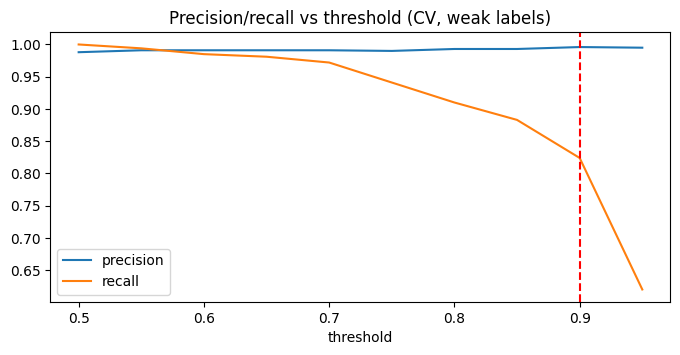

In [6]:
sweep = []
for t in np.arange(0.5, 0.96, 0.05):
    sweep.append((round(t,2), precision_score(weak['label'], cvp>=t, zero_division=0),
                  recall_score(weak['label'], cvp>=t)))
cal = pd.DataFrame(sweep, columns=['threshold','precision','recall']).round(3)
ax = cal.set_index('threshold').plot(figsize=(8,3.5), title='Precision/recall vs threshold (CV, weak labels)')
ax.axvline(0.90, ls='--', c='red'); cal

### A6. Tiering — model decides, rules guard, safety net recalls
* **AUTO-MERGE** — graduated bars by strength evidence (always zero soft conflicts):
  * strength **match**: score ≥ 0.75 — explicit strength agreement is strong evidence;
  * strength **both missing** (supplements/cosmetics — no strength risk exists): score ≥ 0.90, or ≥ 0.85 with near-identical token order;
  * strength **one missing** — the *uniqueness bypass*: auto-merge only if the base name has **exactly one strength in the entire catalog** (ambiguity provably impossible) + token-set ≥ 0.90 + no pack conflict. If the base exists in multiple strengths, no similarity score can justify guessing → HITL.
  * Subset pairs with **no strength on either side** (بانادول كولد vs بانادول كولد اند فلو) are *undecidable by any rule* — they remain in HITL by design; only full word-reorder duplicates auto-merge.
* **HITL**: score ≥ 0.60, **or** any high-overlap pair the model under-scores (`full_tsr ≥ 0.90 & base_sim ≥ 0.85`, no hard conflict — the *safety net*), **or** one-side-missing strength with score ≥ 0.50. These go to the n8n → Telegram review queue.
* **AUTO-REJECT**: everything else, plus every hard conflict regardless of score.

In [7]:
no_soft_conflict = (P['form_state']!='conflict') & (P['size_marker_state']!='conflict') & (P['manufacturer_state']!='conflict')
no_pack_conflict = P['pack_size_state'] != 'conflict'

# --- strength-uniqueness bypass for one_missing pairs ---
# Merging a missing-strength name is safe ONLY when ambiguity is provably impossible:
# the base name has exactly one strength anywhere in the catalog.
# (بروفين exists as 200/400/600 -> plain 'بروفين اقراص' can never auto-merge;
#  نيزابكس exists in one strength only -> plain 'نيزابكس شامبو' safely can.)
base_n_strengths = attrs.dropna(subset=['strength']).groupby('base_name')['strength'].nunique()
P['base_uniq'] = (P['base_name_a'].map(base_n_strengths).fillna(0) <= 1) & \
                 (P['base_name_b'].map(base_n_strengths).fillna(0) <= 1)
one_missing_safe = (P['strength_state']=='one_missing') & P['base_uniq'] & \
                   (P['full_tsr']>=0.90) & (P['base_sim']>=0.95) & \
                   no_soft_conflict & no_pack_conflict

# --- graduated auto-merge bars by strength evidence ---
# Pairs with matching strength or word-reordered duplicates are gated on LEXICAL
# evidence, not only the model score: the RF treats strength-missingness as a feature
# and systematically under-scores some safe pairs, while lexical+attribute evidence
# is decisive. Subset pairs with no strength on either side (بانادول كولد vs
# بانادول كولد اند فلو) are undecidable by any rule and stay in HITL by design.
auto_merge = no_soft_conflict & (
      ((P['strength_state']=='match') & no_pack_conflict &
           ((P['score']>=0.75) | ((P['full_tsr']>=0.90) & (P['base_sim']>=0.90)))) |
      ((P['strength_state']=='both_missing') & ((P['score']>=0.90) |
           ((P['core_sort']>=0.92) & no_pack_conflict & (P['manufacturer_state']!='conflict')))) |
      one_missing_safe )
safety_net = (~auto_merge) & (~hard_conflict) & (P['manufacturer_state']!='conflict') & \
             (P['full_tsr']>=0.90) & (P['base_sim']>=0.85)
hitl = (~auto_merge) & (~hard_conflict) & (
          (P['score']>=0.60) | safety_net |
          ((P['score']>=0.50) & (P['strength_state']=='one_missing')) )
P['tier'] = np.select([hard_conflict, auto_merge, hitl],
                      ['auto_reject','auto_merge','hitl'], default='auto_reject')
print(P['tier'].value_counts().to_dict())
print("one_missing pairs auto-merged via uniqueness bypass:", int(one_missing_safe.sum()))
print("safety-net rescues (model score < 0.60 but routed to HITL):",
      int((safety_net & (P['score']<0.60)).sum()))

{'auto_reject': 9264, 'auto_merge': 856, 'hitl': 565}
one_missing pairs auto-merged via uniqueness bypass: 184
safety-net rescues (model score < 0.60 but routed to HITL): 525


### A7. Constrained clustering → master product IDs
Connected components over **auto-merge edges only**, then two guards: (1) no cluster may contain two different strengths — kills chain-merges across drug families by construction; (2) suspiciously large clusters (>8 names) are dissolved into the HITL queue instead of trusted.

In [8]:
G = nx.Graph(); G.add_nodes_from(range(len(attrs)))
G.add_edges_from(P.loc[P['tier']=='auto_merge', ['i','j']].itertuples(index=False))
master = np.arange(len(attrs)); viol = big = 0
for comp in nx.connected_components(G):
    comp = list(comp)
    strengths = set(attrs.iloc[comp]['strength'].dropna())
    if len(strengths) > 1: viol += 1; continue          # dissolve: keep singletons
    if len(comp) > 8:      big  += 1; continue          # dissolve -> HITL review
    for n in comp: master[n] = min(comp)
attrs['master_idx'] = master
print(f"guards triggered: strength-violation clusters={viol}, oversized clusters={big}")
print(f"{len(attrs):,} raw names -> {attrs['master_idx'].nunique():,} master products "
      f"({len(attrs)-attrs['master_idx'].nunique()} variants merged)")

# canonical name = highest-transaction variant in each cluster
tx_count = sales['product_name'].value_counts()
attrs['tx'] = attrs['raw'].map(tx_count).fillna(0)
canon = attrs.sort_values('tx', ascending=False).groupby('master_idx')['raw'].first()
attrs['canonical_name'] = attrs['master_idx'].map(canon)
attrs[attrs.groupby('master_idx')['raw'].transform('count')>2][['raw','canonical_name']].head(8)

guards triggered: strength-violation clusters=32, oversized clusters=0
5,045 raw names -> 4,370 master products (675 variants merged)


,raw,canonical_name
5,تيراميسين مرهم للعين س-ج *,تيراميسين مرهم للعين س-ج *
8,بولى فريش قطرة س ج/اوركيديا,بولى فريش قطرةا
12,ديبوفيت ب12(1مج/مل) 5امبول س ج/العامرية,ديبوفيت ب12(1مج/مل)5امبول س ج/العامرية
23,فولتارين ايملجل 1% 25جم س ج/نوفارتس,فولتارين ايملجل 1% 100جم س ج/نوفارتس
31,بانادول ادفانس 4 شرايط س ج/الاسكندرية,بانادول ادفانس 4شريط
35,اوتريفين كبار1% نقط أنف س ج/جلاكسو,اوتريفين كبار
36,باى الكوفان 150م(3ش) س ج/الاسكندرية,باى الكوفان
42,فيروجلوبين 30ك س ج/فيتابيوتكس,فيروجلوبين 30كبسول


---
## B. Pharmacies (accounts)
Same machinery, conservative config — pharmacy names are personal names (high collision risk: many «ص محمد …»), so: strip the pharmacy prefix (ص/صيدلية/د), separate route metadata (خط N, branch digits), and require **address corroboration** for auto-merge. Within one supplier, `account_id` is already a reliable key; resolution is only needed **across** suppliers.

In [9]:
PH_PREFIX = re.compile(r'^(ص(يدليه|يدلية)?\s*[./\\-]?\s*|د\s*[/.]\s*|دكتور\s+|فارم\s+)')
ROUTE = re.compile(r'\b(خط|ح|حط)\s*\d+\b|\bنقدي\s*فقط\b|[#*&]+|\b\d{1,3}\b')

def norm_pharmacy(name):
    t = normalize_ar(name)
    t = PH_PREFIX.sub('', t)
    t = ROUTE.sub(' ', t)
    return re.sub(r'\s+', ' ', t).strip()

acc = (sales.groupby(['supplier_id','account_id'])
            .agg(account_name=('account_name','first'),
                 address=('account_address','first'),
                 tx=('id','count'), revenue=('total_amount','sum'))
            .reset_index())
acc['name_norm'] = acc['account_name'].map(norm_pharmacy)
acc['addr_norm'] = acc['address'].fillna('').map(normalize_ar)
print(f"{len(acc):,} supplier-scoped accounts")

vecp = TfidfVectorizer(analyzer='char_wb', ngram_range=(2,4))
Xp = vecp.fit_transform(acc['name_norm'])
nnp = NearestNeighbors(n_neighbors=8, metric='cosine').fit(Xp)
dp, ip = nnp.kneighbors(Xp)
cp = [(i, ip[i,k], 1-dp[i,k]) for i in range(len(acc)) for k in range(1,8)
      if 1-dp[i,k] >= 0.55 and i < ip[i,k]
      and acc.iloc[i]['supplier_id'] != acc.iloc[ip[i,k]]['supplier_id']]   # cross-supplier only
PP = pd.DataFrame(cp, columns=['i','j','ngram_sim']).drop_duplicates(subset=['i','j']).reset_index(drop=True)
PP['name_tsr'] = [fuzz.token_set_ratio(acc.iloc[i]['name_norm'], acc.iloc[j]['name_norm'])/100
                  for i,j in zip(PP['i'],PP['j'])]
PP['name_sort'] = [fuzz.token_sort_ratio(acc.iloc[i]['name_norm'], acc.iloc[j]['name_norm'])/100
                   for i,j in zip(PP['i'],PP['j'])]
PP['addr_sim'] = [fuzz.token_set_ratio(acc.iloc[i]['addr_norm'], acc.iloc[j]['addr_norm'])/100
                  if acc.iloc[i]['addr_norm'] and acc.iloc[j]['addr_norm'] else np.nan
                  for i,j in zip(PP['i'],PP['j'])]
print(f"cross-supplier candidate pairs: {len(PP):,}")

# conservative tiers: auto-merge needs near-identical name AND address corroboration
# auto-merge gate uses token_SORT_ratio: a subset name (حبيب فيصل ⊂ ريمون حبيب فيصل)
# scores 100 on token_set_ratio but is NOT proof of identity -> subsets go to HITL.
PP['tier'] = np.select(
    [ (PP['name_sort']>=0.90) & (PP['addr_sim']>=0.60),
      (PP['name_tsr']>=0.85) | ((PP['name_tsr']>=0.75) & (PP['addr_sim']>=0.60)) ],
    ['auto_merge','hitl'], default='auto_reject')
print(PP['tier'].value_counts().to_dict())

Gp = nx.Graph(); Gp.add_nodes_from(range(len(acc)))
Gp.add_edges_from(PP.loc[PP['tier']=='auto_merge', ['i','j']].itertuples(index=False))
pmaster = np.arange(len(acc))
for comp in nx.connected_components(Gp):
    comp = list(comp)
    if len(comp) > 5: continue
    for n in comp: pmaster[n] = min(comp)
acc['pharmacy_master_idx'] = pmaster
canonp = acc.sort_values('tx', ascending=False).groupby('pharmacy_master_idx')['account_name'].first()
acc['pharmacy_canonical'] = acc['pharmacy_master_idx'].map(canonp)
merged_ph = acc[acc.groupby('pharmacy_master_idx')['account_id'].transform('count')>1]
print(f"{len(acc):,} accounts -> {acc['pharmacy_master_idx'].nunique():,} master pharmacies")
merged_ph.sort_values('pharmacy_master_idx')[['supplier_id','account_name','address','pharmacy_canonical']].head(10)

1,103 supplier-scoped accounts


cross-supplier candidate pairs: 238
{'auto_reject': 146, 'hitl': 89, 'auto_merge': 3}
1,103 accounts -> 1,100 master pharmacies


,supplier_id,account_name,address,pharmacy_canonical
166,59,ص الحرية ارض اللواء 009,اول شارع سيد عبد الرحيم امام مسجد حجاج شارع ال...,ص الحرية ارض اللواء 07
344,60,ص الحرية ارض اللواء 07,شارع المعتمديه من ارض اللواء امام مسجد حجاج,ص الحرية ارض اللواء 07
266,59,س محروس الجديده بولاق 009,امتداد شارع 6 اكتوبر اتجاه العشرين -بولاق الدكرور,محروس الجديدة بولاق - ن س
833,73,محروس الجديدة بولاق - ن س,امتداد شارع 6 اكتوبر اتجاه العشرين بولاق الدكرور,محروس الجديدة بولاق - ن س
270,59,س المروه الهرم 070,ش الهرم عماره بيتزا كينج,ص/المروه ش الهرم خط3
1095,76,ص/المروه ش الهرم خط3,360 ش الهرم عماره بيتزا كينج,ص/المروه ش الهرم خط3


---
## C. Sales reps
Smallest entity (~80 names) but messiest formats: Arabic/Latin mix («MOSTAFA» vs «مصطفي»), role prefixes («محمد عزت-سلز», «سيلز 5 ليلي»), and non-identifying generics («المندوب») which must map to UNKNOWN, never force-matched. A bare first name is treated as **ambiguous, not matchable** — it routes to HITL, because «مصطفي» could be any of several reps. The exception is **channel/system accounts** (كلاستر, اي سبلاي, توريد): those are organizational labels, not people, so identical names across suppliers are the same logical channel and auto-merge.

In [10]:
TRANSLIT = {'mostafa':'مصطفي','mustafa':'مصطفي','mohamed':'محمد','mohammed':'محمد','ahmed':'احمد',
            'ahmad':'احمد','sara':'ساره','sarah':'ساره','nour':'نور','noha':'نهي','aya':'ايه',
            'omar':'عمر','ali':'علي','mahmoud':'محمود','khaled':'خالد','heba':'هبه','mina':'مينا',
            'kareem':'كريم','karim':'كريم','yousef':'يوسف','youssef':'يوسف','laila':'ليلي','mariam':'مريم'}
ROLE = re.compile(r'\b(سلز|سيلز|مندوب|مبيعات|sales?|rep)\b|^د\s+|[-_.]')
GENERIC = {'المندوب','مندوب','sales','user','test',''}

def norm_rep(name):
    t = str(name).lower().strip()
    t = ' '.join(TRANSLIT.get(w, w) for w in t.split())
    t = normalize_ar(t)
    t = ROLE.sub(' ', t)
    t = re.sub(r'\d+', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

reps = (sales.groupby(['supplier_id','rep_name_raw'])
             .agg(tx=('id','count'), revenue=('total_amount','sum')).reset_index())
reps['rep_norm'] = reps['rep_name_raw'].map(norm_rep)
reps['is_generic'] = reps['rep_norm'].isin(GENERIC) | (reps['rep_norm'].str.len() < 3)
print(f"{len(reps)} supplier-scoped rep entries | generic/unidentifiable: {reps['is_generic'].sum()}")

known = reps[~reps['is_generic']].reset_index(drop=True)
rc = [(i, j) for i in range(len(known)) for j in range(i+1, len(known))]
RP = pd.DataFrame(rc, columns=['i','j'])
RP['sim'] = [fuzz.token_set_ratio(known.iloc[i]['rep_norm'], known.iloc[j]['rep_norm'])/100
             for i,j in zip(RP['i'],RP['j'])]
RP['sort'] = [fuzz.token_sort_ratio(known.iloc[i]['rep_norm'], known.iloc[j]['rep_norm'])/100
              for i,j in zip(RP['i'],RP['j'])]
# guard against hub chain-merges: a bare first name («مصطفي», «MOSTAFA») subset-matches every
# «مصطفي X» -> single-token PERSON names can NEVER auto-merge; full-name equality (sort) required.
# EXCEPTION — channel/system accounts (كلاستر, اي سبلاي, توريد...) are organizational labels,
# not people: «توريد» at two suppliers is the same logical channel, so identical normalized
# names auto-merge. The two-humans ambiguity argument only applies to persons.
CHANNEL_RE = re.compile(r'كلاستر|كليستر|سبلاي|توريد|تحصيل|فارما لينك|اوميت|اومت|cluster|supply|omit')
RP['multi_tok'] = [(len(known.iloc[i]['rep_norm'].split())>1) and (len(known.iloc[j]['rep_norm'].split())>1)
                   for i,j in zip(RP['i'],RP['j'])]
RP['both_channel'] = [bool(CHANNEL_RE.search(known.iloc[i]['rep_norm'])) and
                      bool(CHANNEL_RE.search(known.iloc[j]['rep_norm']))
                      for i,j in zip(RP['i'],RP['j'])]
RP['identical'] = [known.iloc[i]['rep_norm'] == known.iloc[j]['rep_norm']
                   for i,j in zip(RP['i'],RP['j'])]
RP['tier'] = np.select(
    [ (RP['both_channel'] & ((RP['identical']) | (RP['sort']>=0.90))),
      (RP['sort']>=0.95) & RP['multi_tok'],
      RP['sim']>=0.80 ],
    ['auto_merge','auto_merge','hitl'], default='auto_reject')
print(RP['tier'].value_counts().to_dict())

Gr = nx.Graph(); Gr.add_nodes_from(range(len(known)))
Gr.add_edges_from(RP.loc[RP['tier']=='auto_merge', ['i','j']].itertuples(index=False))
rmaster = np.arange(len(known))
for comp in nx.connected_components(Gr):
    comp = list(comp)
    for n in comp: rmaster[n] = min(comp)
known['rep_master_idx'] = rmaster
canonr = known.sort_values('tx', ascending=False).groupby('rep_master_idx')['rep_name_raw'].first()
known['rep_canonical'] = known['rep_master_idx'].map(canonr)
reps = reps.merge(known[['supplier_id','rep_name_raw','rep_master_idx','rep_canonical']],
                  on=['supplier_id','rep_name_raw'], how='left')
reps.loc[reps['is_generic'], 'rep_canonical'] = 'UNKNOWN'
print(f"{len(reps)} entries -> {known['rep_master_idx'].nunique()} master reps + UNKNOWN bucket")
known[known.groupby('rep_master_idx')['rep_name_raw'].transform('count')>1][
    ['supplier_id','rep_name_raw','rep_canonical']].head(10)

136 supplier-scoped rep entries | generic/unidentifiable: 3


{'auto_reject': 8666, 'auto_merge': 56, 'hitl': 56}
136 entries -> 105 master reps + UNKNOWN bucket


,supplier_id,rep_name_raw,rep_canonical
0,59,CLUSTER,CLUSTER
6,59,اوميت,اوميت
7,59,اى سبلاى,اي سبلاي
8,59,توريد,توريد
22,59,فارما لينك,فارما لينك
25,59,كلاستر,كلاستر
27,59,مصطفى جمال,مصطفى جمال
33,60,CLUSTER,CLUSTER
34,60,اى سبلاى,اي سبلاي
40,63,فارما لينك,فارما لينك


---
## D. Evaluation & audit artifacts
The 0.90 auto-merge cut was calibrated in §A5. Beyond weak-label CV, we export **stratified audit samples** (auto-merge + HITL pairs) for human verification — auto-merge precision must be confirmed on human-labeled data, and HITL decisions feed the retraining loop. We deliberately claim *no unreviewed merges in the uncertainty band*, not "zero false merges".

In [11]:
audit = pd.concat([
    P[P['tier']=='auto_merge'].sample(min(40, (P['tier']=='auto_merge').sum()), random_state=1),
    P[P['tier']=='hitl'].sample(min(40, (P['tier']=='hitl').sum()), random_state=1),
])[['raw_a','raw_b','score','tier','strength_state','form_state']]
audit['human_label'] = ''      # SAME / DIFFERENT — to be filled by reviewer
audit.to_csv('audit_sample.csv', index=False)

summary = pd.DataFrame({
    'entity': ['products','pharmacies','reps'],
    'raw_entities': [len(attrs), len(acc), len(reps)],
    'master_entities': [attrs['master_idx'].nunique(), acc['pharmacy_master_idx'].nunique(),
                        known['rep_master_idx'].nunique()],
    'auto_merge_pairs': [(P['tier']=='auto_merge').sum(), (PP['tier']=='auto_merge').sum(),
                         (RP['tier']=='auto_merge').sum()],
    'hitl_pairs': [(P['tier']=='hitl').sum(), (PP['tier']=='hitl').sum(), (RP['tier']=='hitl').sum()],
})
summary

,entity,raw_entities,master_entities,auto_merge_pairs,hitl_pairs
0,products,5045,4370,856,565
1,pharmacies,1103,1100,3,89
2,reps,136,105,56,56


## E. Outputs — master tables, HITL queue, resolved fact table

In [12]:
# master dimension tables
prod_master = attrs[['raw','normalized','base_name','strength','form','pack_size','size_marker',
                     'manufacturer','master_idx','canonical_name']].rename(columns={'raw':'product_name'})
prod_master.to_csv('master_products.csv', index=False)
acc.to_csv('master_pharmacies.csv', index=False)
reps.to_csv('master_reps.csv', index=False)

# HITL queue for the n8n -> Telegram review workflow
hitl_q = pd.concat([
    P.loc[P['tier']=='hitl', ['raw_a','raw_b','score']].assign(entity='product'),
    PP[PP['tier']=='hitl'].assign(raw_a=lambda d: acc.iloc[d['i']]['account_name'].values,
                                   raw_b=lambda d: acc.iloc[d['j']]['account_name'].values,
                                   score=lambda d: d['name_tsr'])[['raw_a','raw_b','score']].assign(entity='pharmacy'),
    RP[RP['tier']=='hitl'].assign(raw_a=lambda d: known.iloc[d['i']]['rep_name_raw'].values,
                                   raw_b=lambda d: known.iloc[d['j']]['rep_name_raw'].values,
                                   score=lambda d: d['sim'])[['raw_a','raw_b','score']].assign(entity='rep'),
]).reset_index(drop=True)
hitl_q.insert(0, 'pair_id', hitl_q.index)
hitl_q['decision'] = ''
hitl_q.to_csv('hitl_queue.csv', index=False)

# resolved fact table
resolved = sales.merge(prod_master[['product_name','master_idx','canonical_name']], on='product_name', how='left') \
                .rename(columns={'master_idx':'product_master_id','canonical_name':'product_canonical'})
resolved = resolved.merge(acc[['supplier_id','account_id','pharmacy_master_idx','pharmacy_canonical']],
                          on=['supplier_id','account_id'], how='left') \
                   .rename(columns={'pharmacy_master_idx':'pharmacy_master_id'})
resolved = resolved.merge(reps[['supplier_id','rep_name_raw','rep_master_idx','rep_canonical']],
                          on=['supplier_id','rep_name_raw'], how='left') \
                   .rename(columns={'rep_master_idx':'rep_master_id'})
assert resolved['product_master_id'].notna().all()
assert resolved['pharmacy_master_id'].notna().all()
resolved.to_csv('resolved_sales.csv', index=False)
print(f"resolved_sales.csv: {resolved.shape}")
print('outputs: master_products.csv, master_pharmacies.csv, master_reps.csv, hitl_queue.csv, audit_sample.csv, resolved_sales.csv')

resolved_sales.csv: (9989, 24)
outputs: master_products.csv, master_pharmacies.csv, master_reps.csv, hitl_queue.csv, audit_sample.csv, resolved_sales.csv


---
**Next:** Notebook 3 — star schema + the before/after unification impact analysis (the ROI story), powered by `resolved_sales.csv`. HITL queue feeds the n8n → Telegram review workflow built at the end of the project.